1. [5, 10, 15, 20] auc-roc increase
 

Steps:
1. load best model for moleformer, smiles-bert, chemberta;
2. load [5, 10, 15, 20] dataset;
3. run experiments on different setting, and obtain the auc-roc value for each setting;
4. draw the figure of the auc-roc.

In [84]:
import numpy as np
import pandas as pd 

import torch 
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import auc, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, precision_recall_curve

import os

In [85]:
"""
NA: 
 Molformer
    /project/zhiwei/hf78/vibtcr/data/result/NAbest
 SMILES_BERT
    /project/zhiwei/cq5/PythonWorkSpace/TCRPrediction/tc-hard/embeddings/SMILES_BERT/only-neg-assays
 ChemBERTa
    /project/zhiwei/sj225/TC_Hard/results/HF_CH/NA/1

"""

best_model_path = f"/project/zhiwei/hf78/vibtcr/data/result/NAbest"
# base_path = '/project/zhiwei/cq5/PythonWorkSpace/TCRPrediction/tc-hard/dataset/few_shot_split/pep+cdr3b'
# embed_base_path = '/project/zhiwei/cq5/PythonWorkSpace/TCRPrediction/tc-hard/embeddings/few-shot/moleformer' 

# DATA_PATH = "/project/zhiwei/cq5/PythonWorkSpace/TCRPrediction/tc-hard/dataset/few_shot_split/pep+cdr3b"
DATA_PATH = "/project/zhiwei/cq5/PythonWorkSpace/TCRPrediction/tc-hard/dataset/new_split/pep+cdr3b"

DICT_PATH = "/project/zhiwei/cq5/PythonWorkSpace/TCRPrediction/tc-hard/meta_data"

negative_generate_mode = "only-neg-assays"

model_name = "SMILES_BERT"

In [86]:
#%%
def make_df(df_path):
    df = pd.read_csv(df_path)

    # map_keys = {
    # 'cdr3.beta': 'tcrb',
    # 'antigen.epitope': 'peptide',
    # "label": "label"
    # }
    # df = df.rename(columns={c: map_keys[c] for c in df.columns})

    df['tcrb'] = df['tcrb'].str.replace('O','X')
    df['peptide'] = df['peptide'].str.replace('O','X')

    return df

In [87]:
import pickle

with open(os.path.join(DICT_PATH, model_name, negative_generate_mode, "peptide_dict.pkl"), 'rb') as f:
    peptide_embed_dict = pickle.load(f)

with open(os.path.join(DICT_PATH, model_name, negative_generate_mode, "tcrb_dict.pkl"), 'rb') as f:
    tcrb_embed_dict = pickle.load(f)


In [88]:
# load model
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[512, 512, 512, 256, 256, 256], dropout=0.2):
        super(MLP, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_sizes = hidden_sizes
        self.dropout = dropout
        
        layers = []
        layers.append(nn.Linear(input_size, hidden_sizes[0]))
        layers.append(nn.BatchNorm1d(hidden_sizes[0]))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        
        for i in range(len(hidden_sizes) - 1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
            layers.append(nn.BatchNorm1d(hidden_sizes[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        
        layers.append(nn.Linear(hidden_sizes[-1], output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [89]:
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
batch_size = 32

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [90]:
def get_diff_seen_ratio(seen_ratio = 0):
    
    num_rows_to_replace = int(np.ceil(X_test.shape[0] * seen_ratio))
    rows_to_replace = np.random.choice(X_test.shape[0], size = num_rows_to_replace, replace=False)
    rows_to_place = np.random.choice(X_train.shape[0], size = num_rows_to_replace, replace=False)

    X_new_test = X_test.copy()
    X_new_test[rows_to_replace, :] = X_new_train[rows_to_place, :]

    y_new_test = y_test.copy()
    y_new_test[rows_to_replace] = y_new_train[rows_to_place]


    return X_new_test, y_new_test

In [91]:
def get_result(seen_ratio = 0):

    X_new_test, y_new_test = get_diff_seen_ratio(seen_ratio)
    y_new_pred = model(torch.from_numpy(X_new_test).to(device))
    test_probabilities = torch.softmax(y_new_pred, dim=1)[:, 1].detach().cpu().numpy()
    test_predictions = [1 if prob > 0.5 else 0 for prob in test_probabilities]
    test_auc = roc_auc_score(y_new_test, test_probabilities)
    precision, recall, _ = precision_recall_curve(y_new_test, test_probabilities)

    metrics = {
            'AUROC': test_auc,
            'Accuracy': accuracy_score(y_new_test, test_predictions),
            'Recall': recall_score(y_new_test, test_predictions),
            'Precision': precision_score(y_new_test, test_predictions),
            'F1 score': f1_score(y_new_test, test_predictions),
            'AUPR': auc(recall, precision),
        }

    result_df = pd.DataFrame({
            'score': list(metrics.values()),
            'metrics': list(metrics.keys()),
            'experiment': [dataset_index] * len(metrics)
        })
    
    return result_df

In [92]:
# dataset_index = 1
# X_train, y_train, X_val, y_val, X_test, y_test = load_data(1)

# model = MLP(input_size = 480 + 768, output_size = 2, hidden_sizes = [256], dropout = 0.3)
# model.load_state_dict(torch.load(f"/project/zhiwei/sj225/TC_Hard/results/HF_ME/NA/1/best_mol-esm_{dataset_index}.pth"))
# model.to(device)

# X_new_train = np.vstack([X_train, X_val])
# y_new_train = np.hstack([y_train, y_val])

# result_df = get_result(0.2)
# result_df


In [93]:
def get_embeddings(train_df, validation_df, test_df):
    tcrb_seq_train = np.vstack(train_df['tcrb'].apply(lambda x: tcrb_embed_dict[x]).values)
    tcrb_seq_validation = np.vstack(validation_df['tcrb'].apply(lambda x: tcrb_embed_dict[x]).values)
    tcrb_seq_test = np.vstack(test_df['tcrb'].apply(lambda x: tcrb_embed_dict[x]).values)

    peptide_seq_train = np.vstack(train_df['peptide'].apply(lambda x: peptide_embed_dict[x]).values)
    peptide_seq_validation = np.vstack(validation_df['peptide'].apply(lambda x: peptide_embed_dict[x]).values)
    peptide_seq_test = np.vstack(test_df['peptide'].apply(lambda x: peptide_embed_dict[x]).values)

    label_seq_train = train_df['label'].values
    label_seq_validation = validation_df['label'].values
    label_seq_test = test_df['label'].values

    
    if model_name in ["moleformer", "ChemBERTa"]:
        X_train = np.column_stack((peptide_seq_train, tcrb_seq_train))
        X_validation = np.column_stack((peptide_seq_validation, tcrb_seq_validation))
        X_test = np.column_stack((peptide_seq_test, tcrb_seq_test))
    elif model_name in ["SMILES_BERT"]:
        X_train = np.column_stack((tcrb_seq_train, peptide_seq_train))
        X_validation = np.column_stack((tcrb_seq_validation, peptide_seq_validation))
        X_test = np.column_stack((tcrb_seq_test, peptide_seq_test))
    else:
        raise ValueError("Invalid model name")

    y_train = label_seq_train

    y_validation = label_seq_validation
    
    y_test = label_seq_test

    return X_train, y_train, X_validation, y_validation, X_test, y_test

In [ ]:
seen_ratio_list = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
auc_roc_list = []

for dataset_index in range(5):
    
    # output_model_path = f"/project/zhiwei/cq5/PythonWorkSpace/TCRPrediction/analysis/unseen_ratio/{seen_ratio}"
    auc_roc_list.append([])

    for seen_ratio in seen_ratio_list:
        if model_name == "moleformer":
            model = MLP(input_size = 480 + 768, output_size = 2, hidden_sizes = [256], dropout = 0.3)
            model.load_state_dict(torch.load(f"/project/zhiwei/sj225/TC_Hard/results/HF_ME/NA/1/best_mol-esm_{dataset_index}.pth"))
        elif model_name == "SMILES_BERT":
            model = MLP(input_size = 480 + 768, output_size = 2, hidden_sizes = [256], dropout = 0.3)
            model.load_state_dict(torch.load(f"/project/zhiwei/cq5/PythonWorkSpace/TCRPrediction/tc-hard/saved_models/smiles_bert/only-neg-assays/best_mol-esm_{dataset_index}.pth"))
        elif model_name == "ChemBERTa":
            model = MLP(input_size = 480 + 384, output_size = 2, hidden_sizes = [32], dropout = 0.3)
            model.load_state_dict(torch.load(f"/project/zhiwei/sj225/TC_Hard/results/HF_CH/NA/1/best_mol-esm_{dataset_index}.pth"))
        else:
            raise ValueError("Invalid model name, names can be: moleformer, SMILES_BERT, ChemBERTa")
        model = model.to("cuda:0")


        train_df_path = os.path.join(DATA_PATH, "train", negative_generate_mode, f"train-{dataset_index}.csv")
        validation_df_path = os.path.join(DATA_PATH, "validation", negative_generate_mode, f"validation-{dataset_index}.csv")
        test_df_path = os.path.join(DATA_PATH, "test", negative_generate_mode, f"test-{dataset_index}.csv")

        train_df = make_df(train_df_path)
        validation_df = make_df(validation_df_path)
        test_df = make_df(test_df_path)

        X_train, y_train, X_validation, y_validation, X_test, y_test = get_embeddings(train_df, validation_df, test_df)

        
        X_new_train = np.vstack([X_train, X_validation])
        y_new_train = np.hstack([y_train, y_validation])

        result_df = get_result(seen_ratio)
        print(result_df)
        auc_roc_list[dataset_index].append(result_df.iloc[0]["score"])


auc_roc_list = np.array(auc_roc_list)

mean_auc_roc = auc_roc_list.mean(axis = 0)
print(mean_auc_roc)


In [1]:
mole_former_auc_roc = [0.82392062, 0.95113685, 0.95899605, 0.97341583, 0.97336833, 0.96682442]
smiles_bert_auc_roc = [0.65839726, 0.7445706083919953, 0.7446071075352042, 0.7495811048280915, 0.7504291120191007, 0.7495276859963282]
ChemBERTa_auc_roc = [0.65238413, 0.80428367, 0.82250928, 0.8267358,  0.82261251, 0.80609647]

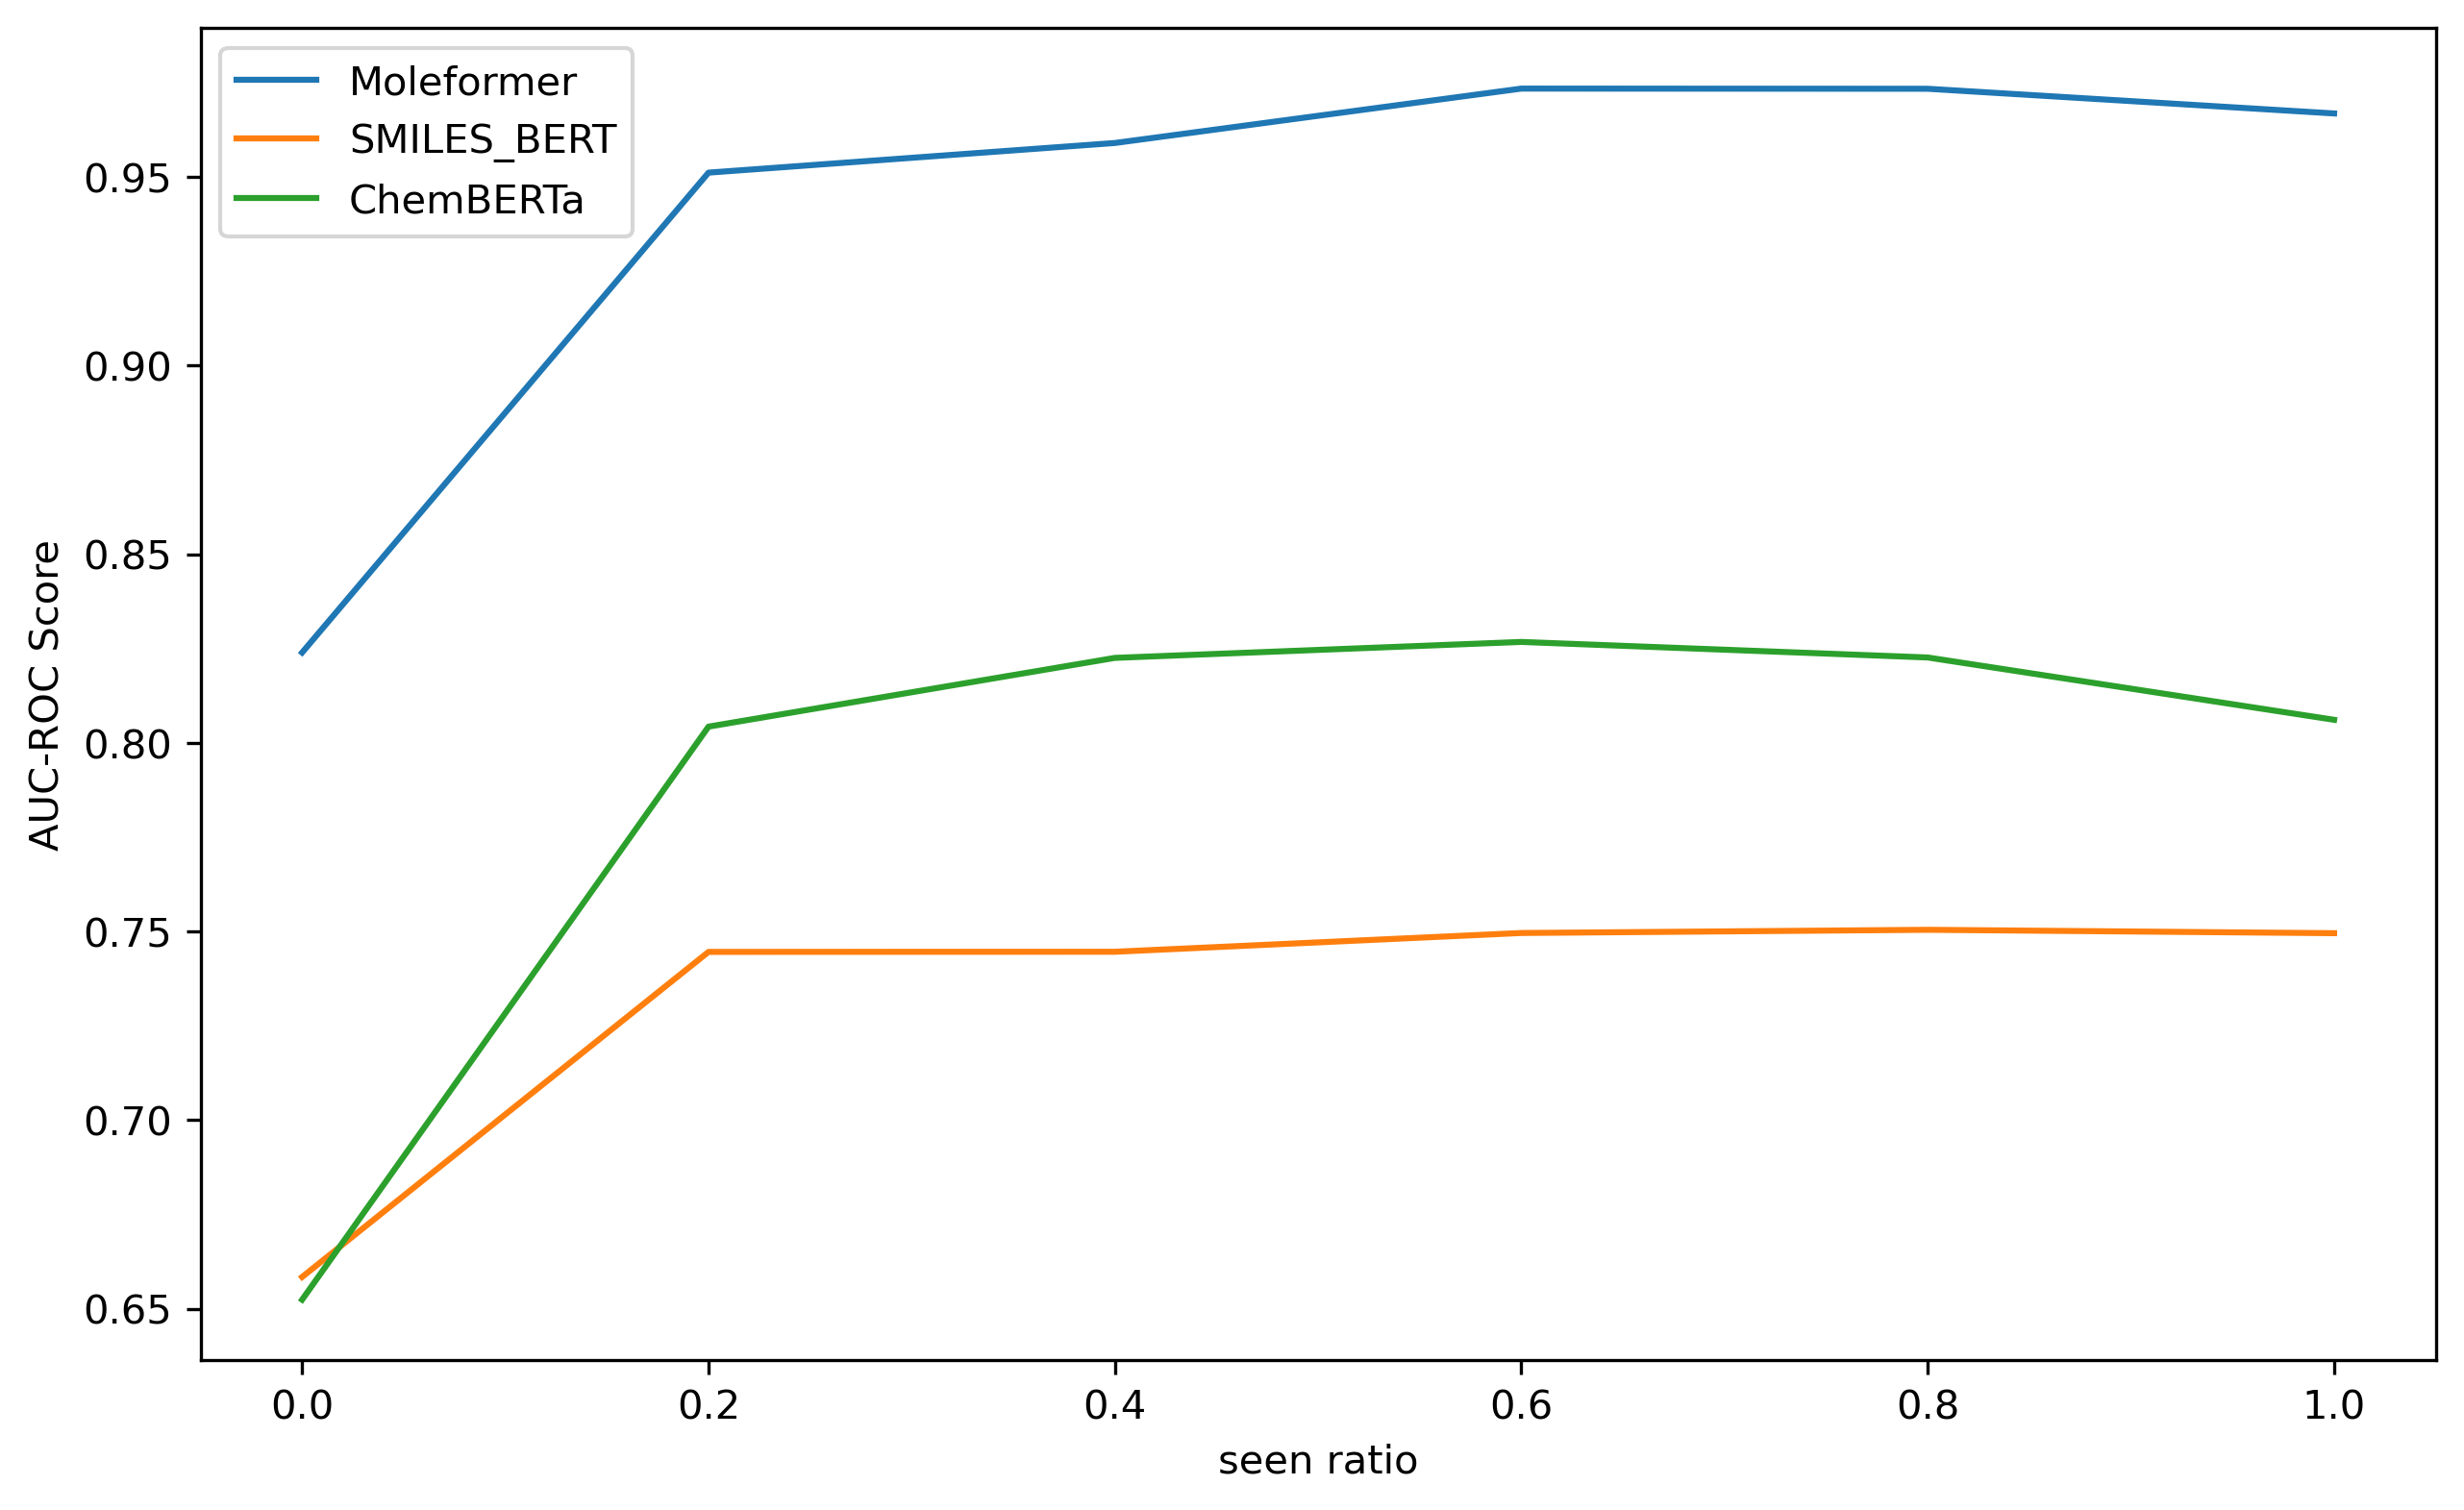

In [3]:
import matplotlib.pyplot as plt

seen_ratio_list = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

plt.figure(figsize=(10, 6), dpi = 300)
plt.xlabel("seen ratio")
plt.ylabel("AUC-ROC Score")
plt.plot(seen_ratio_list, mole_former_auc_roc, label = "Moleformer")
plt.plot(seen_ratio_list, smiles_bert_auc_roc, label = "SMILES_BERT")
plt.plot(seen_ratio_list, ChemBERTa_auc_roc, label = "ChemBERTa")

plt.legend()

0: 0.901

20% seen

1: 0.924796

2: 0.948553

3: 0.947340

4: 0.944642

5: 0.907792 / 0.931580

10: 0.907764 / 0.933113

15: 0.907747 / 0.929772

20: 0.907721 / 0.956605

100: 0.907400 / 0.945554

150: 0.907151 / 0.952375

200: 0.906876 / 0.952898

300: 0.904357 / 0.956077

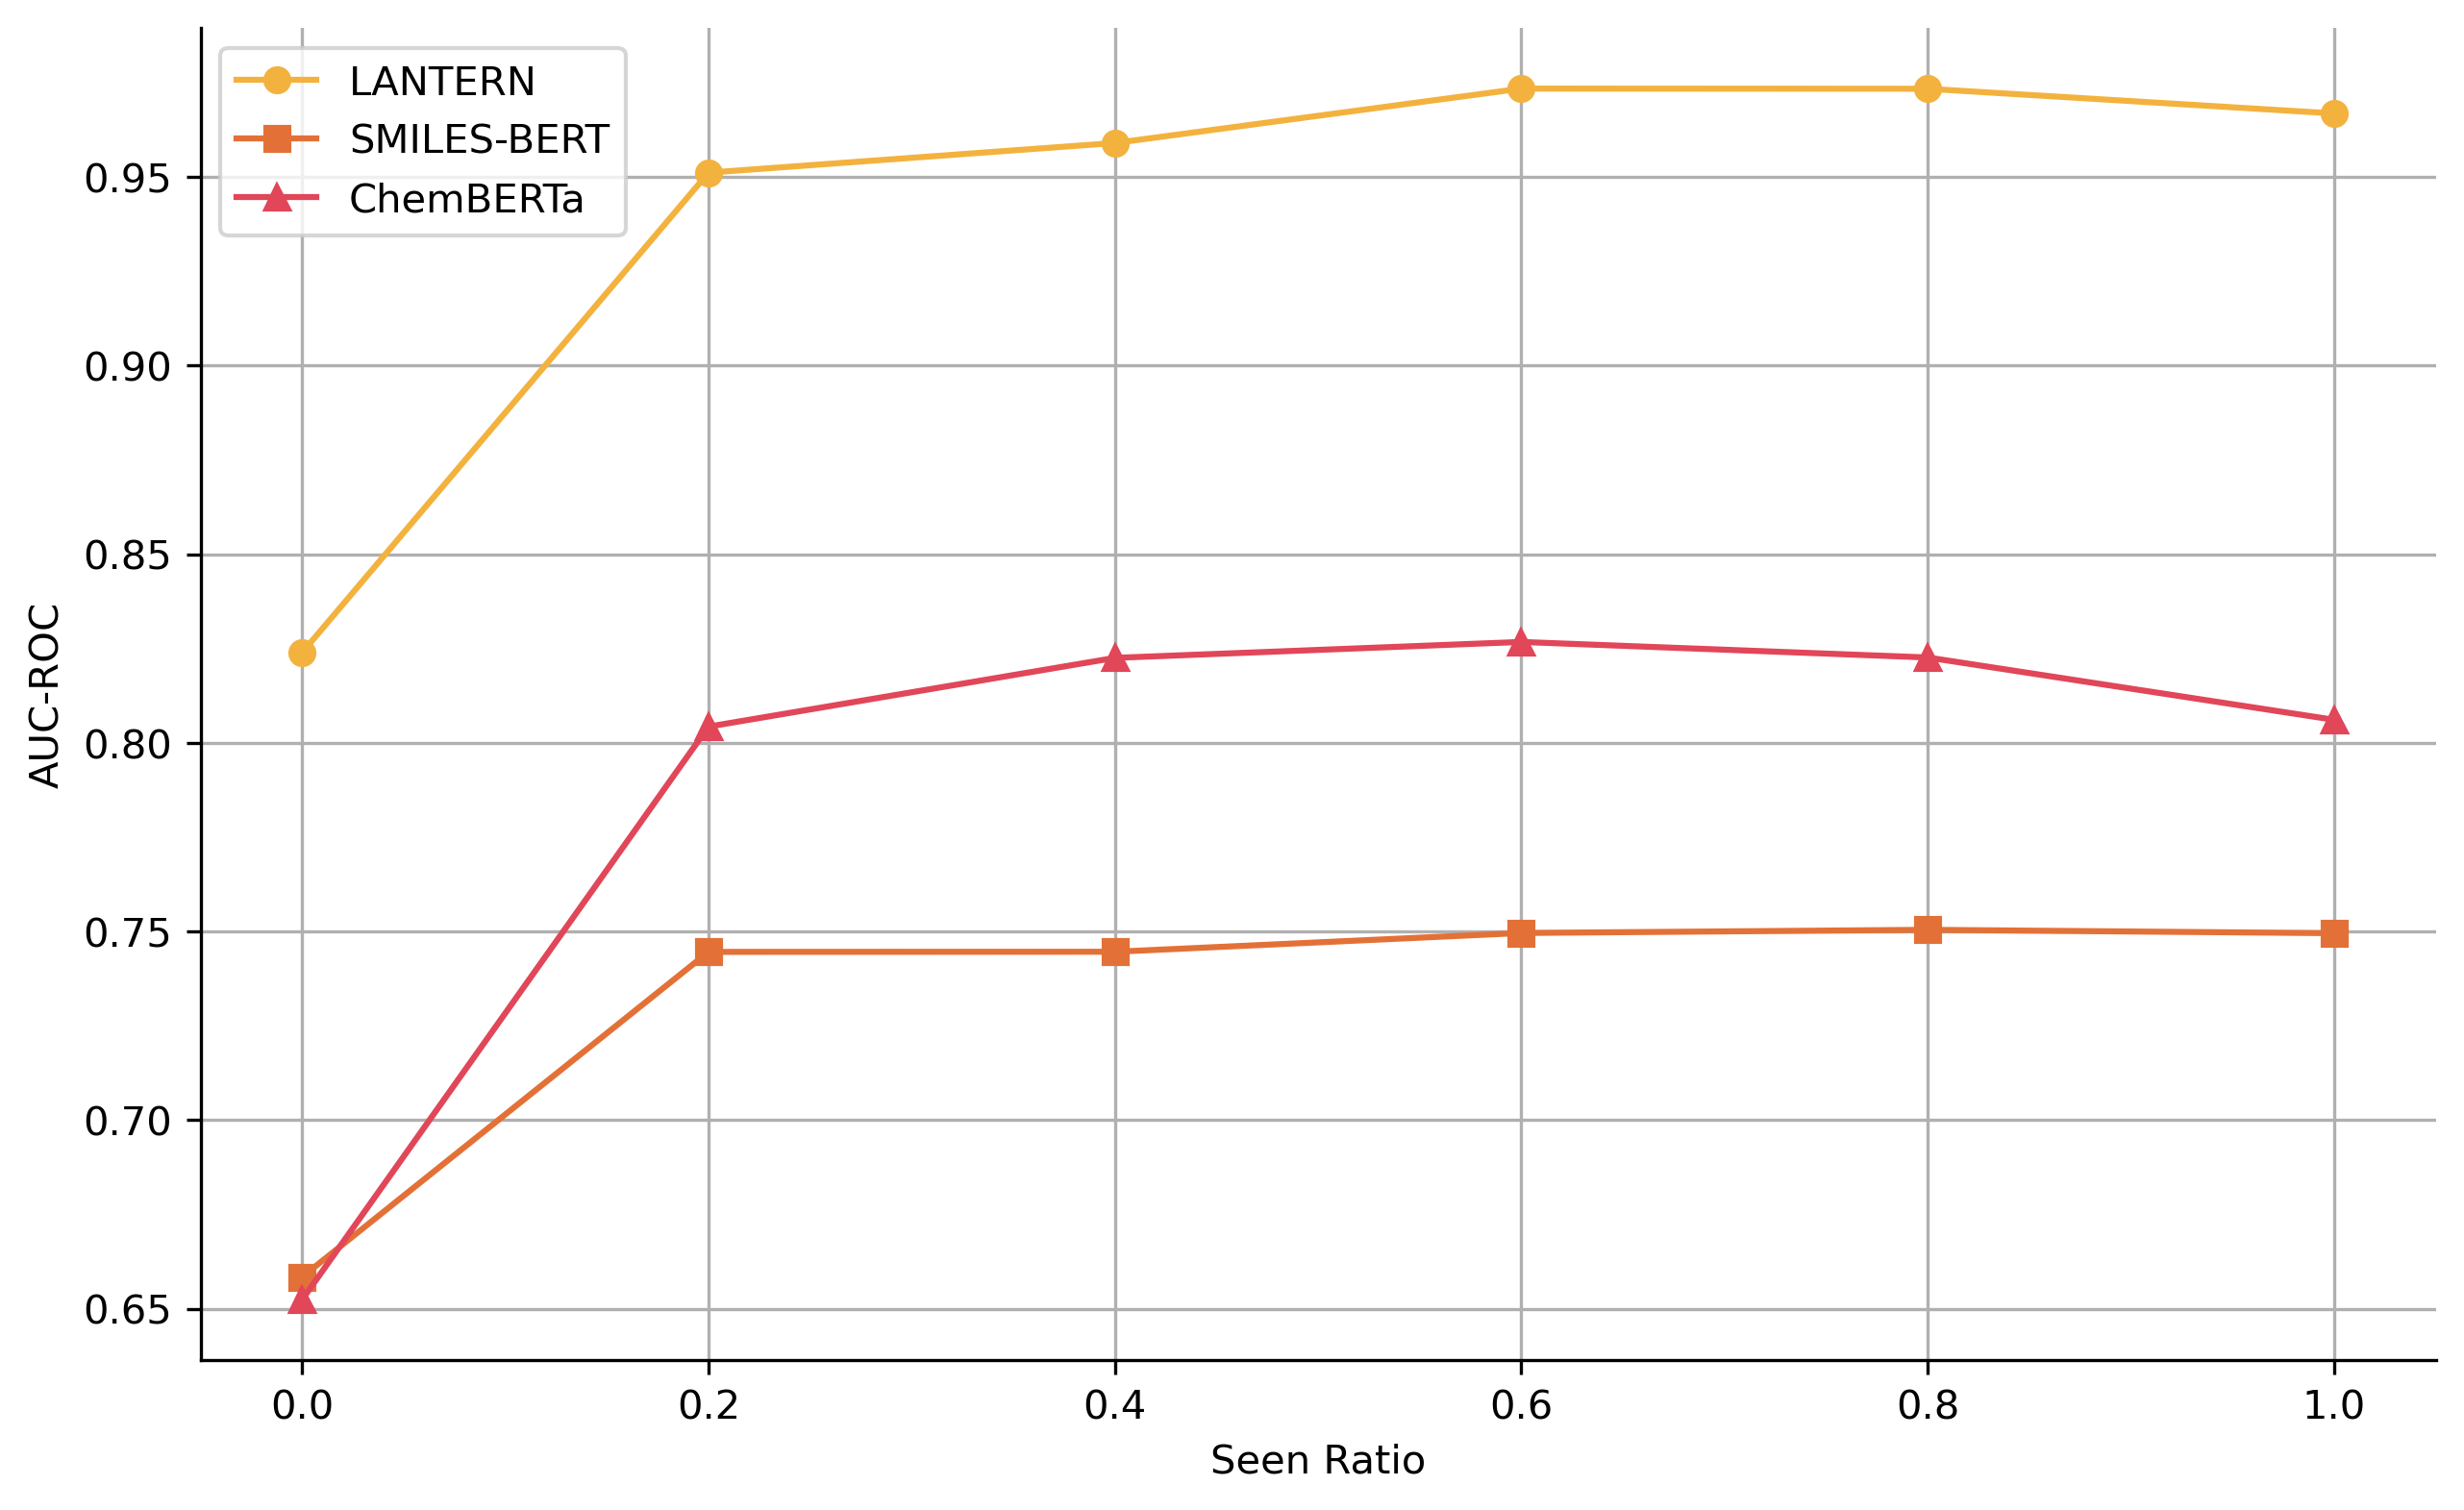

In [4]:
plt.figure(figsize=(10, 6), dpi = 300)
plt.plot(seen_ratio_list, mole_former_auc_roc, marker='o', color = "#F3B23E", label='LANTERN')
plt.plot(seen_ratio_list, smiles_bert_auc_roc, marker='s', color = "#E37137", label='SMILES-BERT')
plt.plot(seen_ratio_list, ChemBERTa_auc_roc, marker='^', color = "#E14659", label='ChemBERTa')

plt.grid(True)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.xlabel('Seen Ratio')
plt.ylabel('AUC-ROC')
# plt.title('AUC-ROC Comparison of Models Over Seen Ratios')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()